In [ ]:
!pip install transformers torch torchvision pillow numpy matplotlib scipy

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
import torch.nn.functional as F


processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b5-finetuned-ade-640-640"
)
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b5-finetuned-ade-640-640"
)
model.eval()

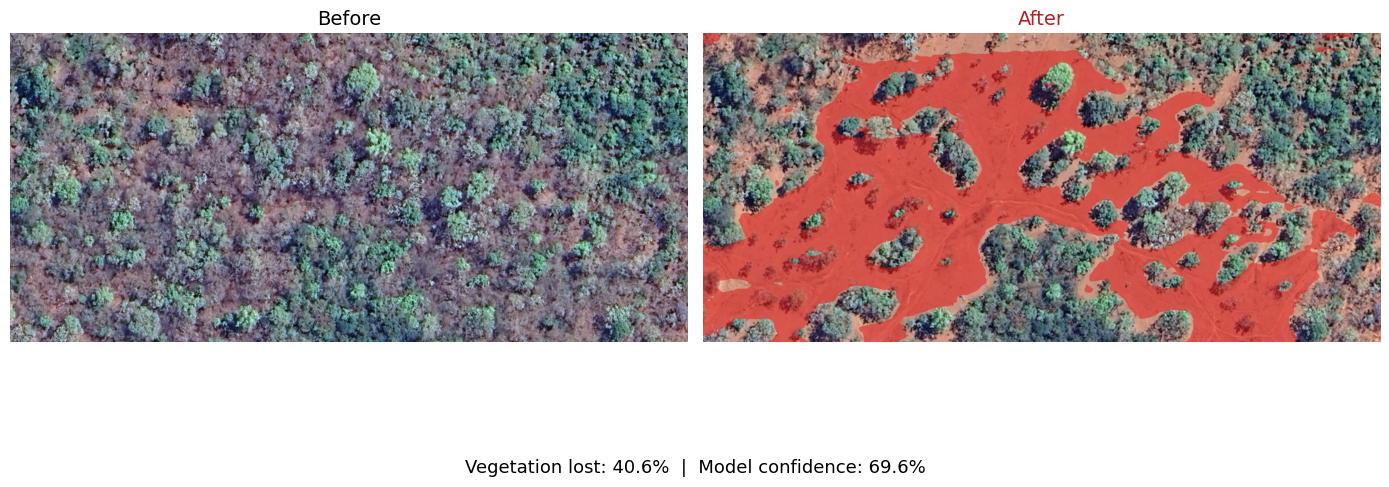


Vegetation lost : 473,413 px  (40.59%)
Model confidence: 69.6%  (before: 77.3%  after: 61.9%)

Total lost tree spots: 32
--------------------------------------------------
  Tree   1 — x=196, y=636  |  18,834 px lost
  Tree   2 — x=899, y=414  |  14,281 px lost
  Tree   3 — x=329, y=266  |  16,177 px lost
  Tree   4 — x=1487, y=451  |  6,842 px lost
  Tree   5 — x=889, y=108  |  11,479 px lost
  Tree   6 — x=1163, y=530  |  12,922 px lost
  Tree   7 — x=721, y=96  |  16,609 px lost
  Tree   8 — x=581, y=560  |  19,676 px lost
  Tree   9 — x=267, y=404  |  17,143 px lost
  Tree  10 — x=570, y=118  |  16,842 px lost
  Tree  11 — x=1113, y=191  |  8,377 px lost
  Tree  12 — x=574, y=426  |  20,047 px lost
  Tree  13 — x=1372, y=575  |  14,107 px lost
  Tree  14 — x=53, y=604  |  19,400 px lost
  Tree  15 — x=1188, y=347  |  11,883 px lost
  Tree  16 — x=786, y=222  |  13,983 px lost
  Tree  17 — x=155, y=491  |  20,051 px lost
  Tree  18 — x=715, y=380  |  19,303 px lost
  Tree  19 — x=4

In [23]:
BEFORE_PATH = "before.jpg"
AFTER_PATH = "after.jpg"

VEG_CLASSES = [4, 17, 72]
CONFIDENCE = 0.45

model.eval()

before = Image.open(BEFORE_PATH).convert("RGB")
after = Image.open(AFTER_PATH).convert("RGB")

after = after.resize(before.size, Image.LANCZOS)

width, height = before.size


def get_vegetation_mask(image):
    inputs = processor(images=image, return_tensors="pt")

    with torch.no_grad():
        output = model(**inputs)

    logits = output.logits

    logits = F.interpolate(
        logits,
        size=(height, width),
        mode="bilinear",
        align_corners=False
    )

    probabilities = torch.softmax(logits, dim=1).squeeze(0).numpy()

    vegetation_probability = sum(
        probabilities[class_id] for class_id in VEG_CLASSES
    )

    confidence = float(probabilities.max(axis=0).mean() * 100)

    vegetation_mask = (
        vegetation_probability >= CONFIDENCE
    ).astype(np.uint8)

    return vegetation_mask, confidence


before_mask, before_confidence = get_vegetation_mask(before)
after_mask, after_confidence = get_vegetation_mask(after)


lost_vegetation = (
    (before_mask == 1) & (after_mask == 0)
).astype(np.uint8)


after_array = np.array(after)
result_image = after_array.copy()

red = np.array([220, 30, 30])

result_image[lost_vegetation == 1] = (
    0.45 * after_array[lost_vegetation == 1]
    + 0.55 * red
).astype(np.uint8)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(before)
axes[0].set_title("Before", fontsize=14)

axes[1].imshow(result_image)
axes[1].set_title("After", fontsize=14, color="firebrick")

for ax in axes:
    ax.axis("off")


lost_pixels = int(lost_vegetation.sum())
total_pixels = lost_vegetation.size

vegetation_lost_percent = (
    100 * lost_pixels / total_pixels
)

average_confidence = (
    before_confidence + after_confidence
) / 2


fig.suptitle(
    f"Vegetation lost: {vegetation_lost_percent:.1f}%  |  "
    f"Model confidence: {average_confidence:.1f}%",
    fontsize=13,
    y=0.02
)

plt.tight_layout()
plt.savefig(
    "deforestation_result.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


print(
    f"\nVegetation lost : {lost_pixels:,} px "
    f"({vegetation_lost_percent:.2f}%)"
)

print(
    f"Model confidence: {average_confidence:.1f}% "
    f"(before: {before_confidence:.1f}%  "
    f"after: {after_confidence:.1f}%)"
)


from sklearn.cluster import KMeans


def find_lost_trees(mask, clusters=32):
    coordinates = np.column_stack(np.where(mask))

    if len(coordinates) == 0:
        return [], [], 0

    number_of_clusters = min(clusters, len(coordinates))

    kmeans = KMeans(
        n_clusters=number_of_clusters,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(coordinates)

    return coordinates, labels, number_of_clusters


coordinates, labels, number_of_trees = find_lost_trees(
    lost_vegetation,
    clusters=32
)


print(f"\nTotal lost tree spots: {number_of_trees}")
print("-" * 50)

if number_of_trees > 0:

    for label in range(number_of_trees):
        points = coordinates[labels == label]

        y = int(points[:, 0].mean())
        x = int(points[:, 1].mean())

        lost_area = len(points)

        print(
            f"  Tree {label + 1:>3} — "
            f"x={x}, y={y}  |  "
            f"{lost_area:,} px lost"
        )

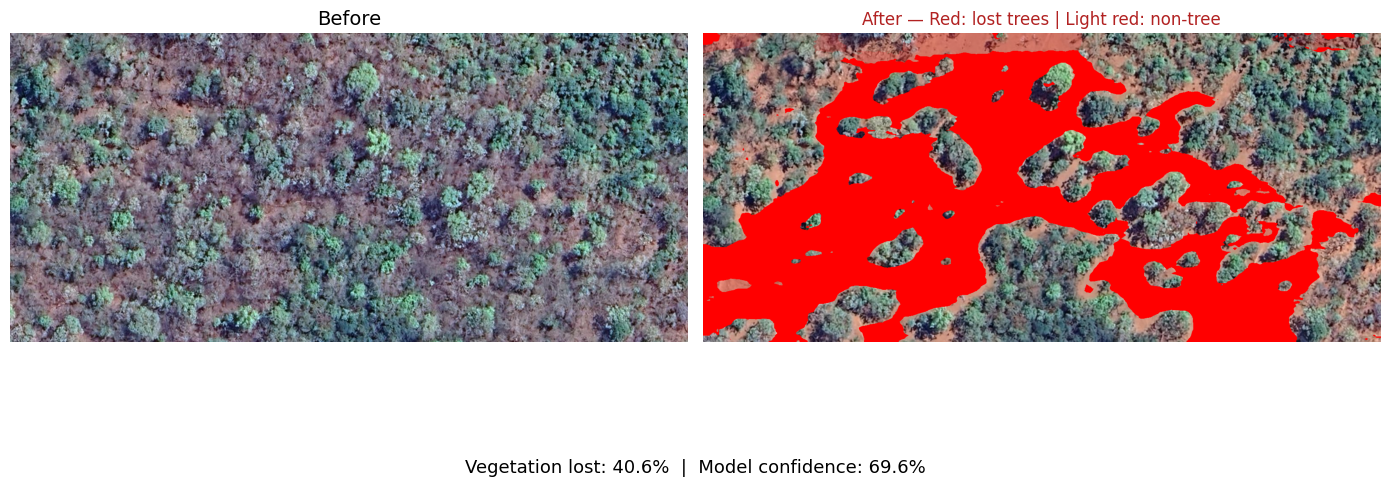


Vegetation lost : 473,413 px  (40.59%)
Model confidence: 69.6%  (before: 77.3%  after: 61.9%)

Missing tree clusters: 23
---------------------------------------------
  Cluster  1 — center pixel: x=16, y=11  |  size: 922 px
  Cluster  2 — center pixel: x=690, y=6  |  size: 121 px
  Cluster  3 — center pixel: x=1373, y=3  |  size: 56 px
  Cluster  4 — center pixel: x=1426, y=1  |  size: 67 px
  Cluster  5 — center pixel: x=1496, y=5  |  size: 843 px
  Cluster  6 — center pixel: x=1353, y=7  |  size: 23 px
  Cluster  7 — center pixel: x=1385, y=14  |  size: 55 px
  Cluster  8 — center pixel: x=1387, y=30  |  size: 48 px
  Cluster  9 — center pixel: x=1425, y=34  |  size: 30 px
  Cluster 10 — center pixel: x=1470, y=38  |  size: 432 px
  Cluster 11 — center pixel: x=688, y=412  |  size: 468,976 px
  Cluster 12 — center pixel: x=815, y=121  |  size: 170 px
  Cluster 13 — center pixel: x=201, y=181  |  size: 153 px
  Cluster 14 — center pixel: x=2, y=192  |  size: 11 px
  Cluster 15 — cent

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from PIL import Image

BEFORE_PATH = "before.jpg"
AFTER_PATH = "after.jpg"
VEG_CLASSES = [4, 17, 72]
CONFIDENCE = 0.45

model.eval()

before = Image.open(BEFORE_PATH).convert("RGB")
after = Image.open(AFTER_PATH).convert("RGB")
after = after.resize(before.size, Image.LANCZOS)

SIZE = before.size


def get_veg_mask(img):
    inputs = processor(images=img, return_tensors="pt")

    with torch.no_grad():
        logits = model(**inputs).logits

    upsampled = F.interpolate(
        logits,
        size=(SIZE[1], SIZE[0]),
        mode="bilinear",
        align_corners=False
    )

    probs = torch.softmax(upsampled, dim=1).squeeze(0).numpy()
    veg_prob = sum(probs[c] for c in VEG_CLASSES)
    confidence = float(probs.max(axis=0).mean() * 100)

    mask = (veg_prob >= CONFIDENCE).astype(np.uint8)

    return mask, confidence


mask_before, conf_before = get_veg_mask(before)
mask_after, conf_after = get_veg_mask(after)

loss_mask = (
    (mask_before == 1) & (mask_after == 0)
).astype(np.uint8)

non_tree_mask = (mask_after == 0).astype(np.uint8)

after_np = np.array(after)
result = after_np.copy()

result[non_tree_mask == 1] = (
    0.75 * after_np[non_tree_mask == 1]
    + 0.25 * np.array([220, 30, 30])
).astype(np.uint8)

result[loss_mask == 1] = [255, 0, 0]


def cluster_regions(mask, eps=5, min_samples=10):
    coords = np.column_stack(np.where(mask))

    if len(coords) == 0:
        return [], [], 0

    db = DBSCAN(
        eps=eps,
        min_samples=min_samples
    ).fit(coords)

    labels = db.labels_

    num_clusters = len(set(labels))
    if -1 in labels:
        num_clusters -= 1

    return coords, labels, num_clusters


coords, labels, num_missing = cluster_regions(loss_mask)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(before)
axes[0].set_title("Before", fontsize=14)

axes[1].imshow(result)
axes[1].set_title(
    "After — Red: lost trees | Light red: non-tree",
    fontsize=12,
    color="firebrick"
)

for ax in axes:
    ax.axis("off")


px_lost = int(loss_mask.sum())
px_total = loss_mask.size
pct = 100 * px_lost / px_total
avg_conf = (conf_before + conf_after) / 2


fig.suptitle(
    f"Vegetation lost: {pct:.1f}%  |  "
    f"Model confidence: {avg_conf:.1f}%",
    fontsize=13,
    y=0.02
)

plt.tight_layout()
plt.savefig(
    "deforestation_result.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print(f"\nVegetation lost : {px_lost:,} px ({pct:.2f}%)")
print(
    f"Model confidence: {avg_conf:.1f}% "
    f"(before: {conf_before:.1f}%  after: {conf_after:.1f}%)"
)

print(f"\nMissing tree clusters: {num_missing}")
print("-" * 45)

if num_missing > 0:
    unique_labels = [label for label in set(labels) if label != -1]

    for label in unique_labels:
        points = coords[labels == label]

        y = int(points[:, 0].mean())
        x = int(points[:, 1].mean())

        print(
            f"  Cluster {label + 1:>2} — "
            f"center pixel: x={x}, y={y}  |  "
            f"size: {len(points):,} px"
        )